Loading data...
Total observations: 1971

IMPLEMENTING LEE ET AL. (2015) SECCHI DEPTH MODEL
Using K_PAR as proxy for Kd_tr
✓ Lee simple model (ZSD ≈ 1/Kd) calculated
Using K_PAR as proxy for Kd_tr
✓ Lee full model calculated

LEE MODEL PERFORMANCE

Lee Simple Model (ZSD ≈ 1/Kd):
  N samples: 1971
  R²:   -0.0095
  RMSE: 8.80 m
  MAE:  6.95 m

Lee Full Model:
  N samples: 1971
  R²:   0.1997
  RMSE: 7.83 m
  MAE:  5.60 m

LOADING ML MODEL RESULTS FOR COMPARISON

                         Model    N        R2     RMSE      MAE
         Ensemble (your model) 1971  0.743000 4.390000 3.000000
Gradient Boosting (your model) 1971  0.740000 4.420000 3.100000
    Random Forest (your model) 1971  0.735000 4.460000 3.200000
                Lee Full Model 1971  0.199719 7.832488 5.600026
             Lee Simple (1/Kd) 1971 -0.009544 8.797135 6.945846

Saved: ../results/lee_vs_ml_comparison.csv

Saved: ../results/lee_model_comparison.png


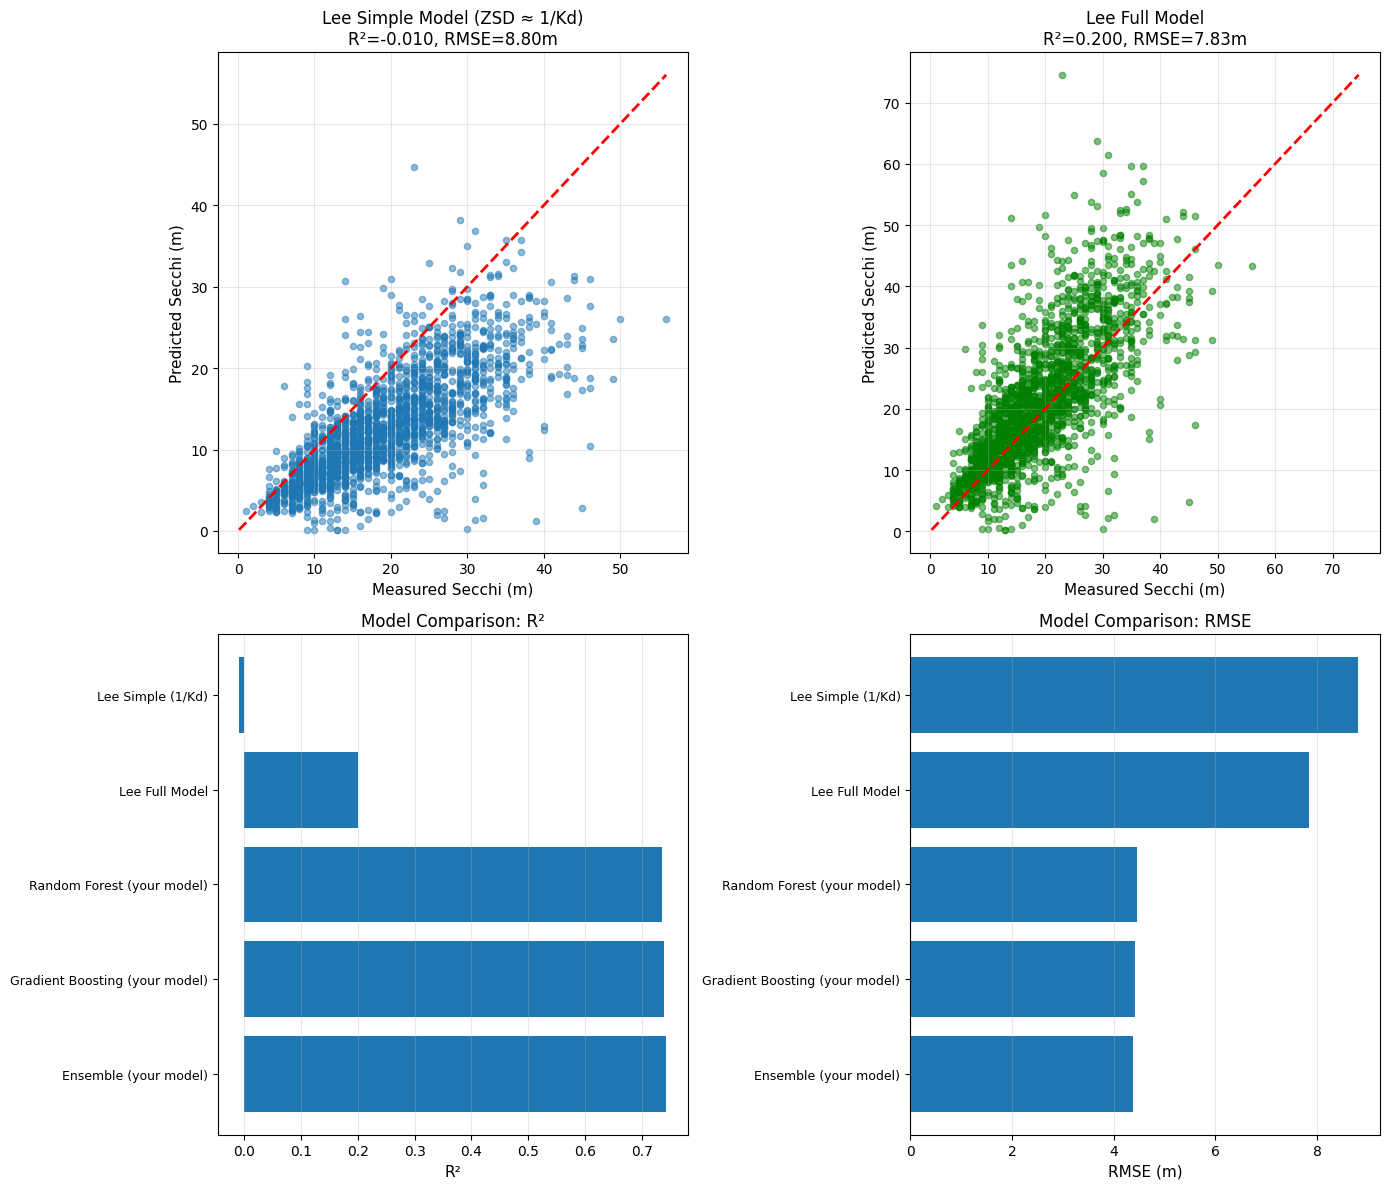

Saved: ../results/lee_model_residuals.png


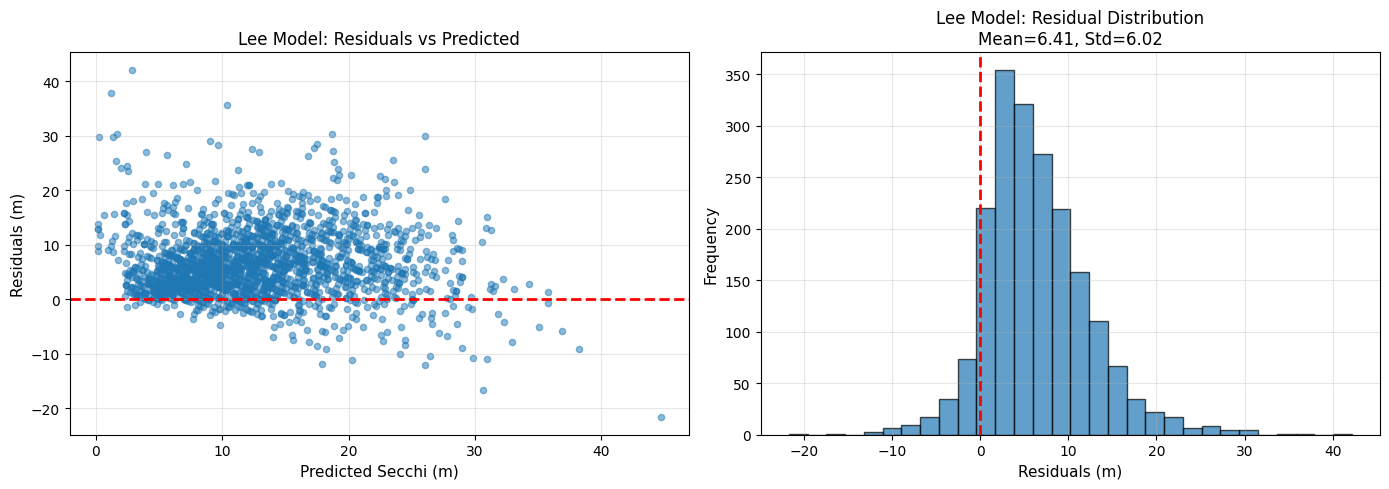


RECOMMENDATION: LEE MODEL vs ML MODELS

Best performing model: Ensemble (your model)
  R²:   0.7430
  RMSE: 4.39 m

✓ ML models outperform the Lee model
  This suggests your features capture additional complexity
  Improvement over Lee model: 54.3%

ANALYSIS COMPLETE!


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

# Remove rows with missing Secchi
df = df[df['Secchi'].notna()].copy()

print(f"Total observations: {len(df)}")

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# ============================================================================
# LEE ET AL. (2015) MODEL IMPLEMENTATION
# ============================================================================

print("\n" + "="*80)
print("IMPLEMENTING LEE ET AL. (2015) SECCHI DEPTH MODEL")
print("="*80)

"""
Lee et al. (2015) Secchi Depth Model:

ZSD ≈ 1 / (2.5 * Kd_tr)

where Kd_tr is the minimum diffuse attenuation coefficient 
in the visible spectrum (the "transparent window")

Full formula (Eq. 33 from Lee et al. 2015):
ZSD = (1 / (2.5 * min(Kd))) * ln(|0.14 - Rrs_pc| / Ct_r)

Simplified (Eq. 36, rule of thumb):
ZSD ≈ 1 / Kd_tr

Key insight: Secchi depth is primarily controlled by Kd at the 
wavelength of maximum water transparency, NOT by beam attenuation (c)
"""

def calculate_kd_from_iops(a, bb, theta_sun=30):
    """
    Calculate Kd from absorption (a) and backscattering (bb)
    Using Lee et al. (2005) model
    
    Parameters:
    -----------
    a : float or array
        Absorption coefficient (m^-1)
    bb : float or array
        Backscattering coefficient (m^-1)
    theta_sun : float
        Solar zenith angle in degrees
        
    Returns:
    --------
    Kd : float or array
        Diffuse attenuation coefficient (m^-1)
    """
    # Convert sun angle to radians
    theta_rad = np.deg2rad(theta_sun)
    
    # Lee et al. (2005) model for Kd
    # Kd ≈ (1 + m0 * θ) * a + m1 * (1 - m2 * exp(-m3 * a)) * bb
    
    m0 = 0.005
    m1 = 4.259
    m2 = 0.52
    m3 = 10.8
    
    chi = np.log10(a / bb)
    chi = np.clip(chi, -2, 2)  # Keep chi in reasonable range
    
    m0_theta = m0 + 0.265 * theta_rad
    
    Kd = (1 + m0_theta * np.cos(theta_rad)) * a + m1 * (1 - m2 * np.exp(-m3 * a)) * bb
    
    return Kd

def lee_secchi_model(df, use_full_model=False):
    """
    Calculate Secchi depth using Lee et al. (2015) model
    
    Parameters:
    -----------
    df : DataFrame
        Must contain K_PAR or ability to calculate Kd
    use_full_model : bool
        If True, use full model with contrast threshold
        If False, use simplified rule of thumb
        
    Returns:
    --------
    ZSD_predicted : array
        Predicted Secchi depth (m)
    """
    
    # Method 1: If we have K_PAR (proxy for Kd)
    if 'K_PAR' in df.columns:
        print("Using K_PAR as proxy for Kd_tr")
        Kd_tr = df['K_PAR'].values
        
    # Method 2: If we have K_PAR_SLOPE
    elif 'K_PAR_SLOPE' in df.columns:
        print("Using K_PAR_SLOPE as proxy for Kd_tr")
        Kd_tr = df['K_PAR_SLOPE'].values
        
    # Method 3: Calculate from PAR measurements
    elif 'PAR' in df.columns and 'DEPTH' in df.columns:
        print("Calculating Kd from PAR profile")
        # This would require groupby CAST_COUNT and calculate Kd per cast
        # For simplicity, use K_PAR if available
        if 'K_PAR' in df.columns:
            Kd_tr = df['K_PAR'].values
        else:
            raise ValueError("Cannot calculate Kd - insufficient data")
    else:
        raise ValueError("Need K_PAR, K_PAR_SLOPE, or PAR+DEPTH to calculate Kd")
    
    # Remove invalid Kd values
    Kd_tr = np.where(Kd_tr <= 0, np.nan, Kd_tr)
    Kd_tr = np.where(np.isinf(Kd_tr), np.nan, Kd_tr)
    
    if use_full_model:
        # Full Lee et al. (2015) model (Eq. 33)
        # ZSD = (1 / (2.5 * Kd_tr)) * ln(|rT - rw| / Ct_r)
        
        # Disk reflectance (white disk)
        rT = 0.85  # sr^-1 (reflectance ~0.85, divided by π)
        
        # Water reflectance at perceived color
        # Approximation: assume very low for blue/clear water
        rw_pc = 0.01  # sr^-1 (approximate)
        
        # Contrast threshold
        Ct_r = 0.013  # sr^-1 (from Lee et al. 2015)
        
        # Full model
        ZSD_predicted = (1 / (2.5 * Kd_tr)) * np.log(np.abs(rT - rw_pc) / Ct_r)
        
    else:
        # Simplified rule of thumb (Eq. 36)
        # ZSD ≈ 1 / Kd_tr
        ZSD_predicted = 1.0 / Kd_tr
    
    return ZSD_predicted

# ============================================================================
# CALCULATE LEE MODEL PREDICTIONS
# ============================================================================

# Try both versions
try:
    ZSD_lee_simple = lee_secchi_model(df, use_full_model=False)
    print("✓ Lee simple model (ZSD ≈ 1/Kd) calculated")
except Exception as e:
    print(f"✗ Lee simple model failed: {e}")
    ZSD_lee_simple = None

try:
    ZSD_lee_full = lee_secchi_model(df, use_full_model=True)
    print("✓ Lee full model calculated")
except Exception as e:
    print(f"✗ Lee full model failed: {e}")
    ZSD_lee_full = None

# ============================================================================
# EVALUATE LEE MODEL
# ============================================================================

print("\n" + "="*80)
print("LEE MODEL PERFORMANCE")
print("="*80)

results = []

# Evaluate simple model
if ZSD_lee_simple is not None:
    mask = ~np.isnan(ZSD_lee_simple) & ~np.isnan(df['Secchi'].values)
    
    if mask.sum() > 0:
        ZSD_obs = df['Secchi'].values[mask]
        ZSD_pred = ZSD_lee_simple[mask]
        
        rmse = np.sqrt(mean_squared_error(ZSD_obs, ZSD_pred))
        r2 = r2_score(ZSD_obs, ZSD_pred)
        mae = mean_absolute_error(ZSD_obs, ZSD_pred)
        
        print(f"\nLee Simple Model (ZSD ≈ 1/Kd):")
        print(f"  N samples: {mask.sum()}")
        print(f"  R²:   {r2:.4f}")
        print(f"  RMSE: {rmse:.2f} m")
        print(f"  MAE:  {mae:.2f} m")
        
        results.append({
            'Model': 'Lee Simple (1/Kd)',
            'N': mask.sum(),
            'R2': r2,
            'RMSE': rmse,
            'MAE': mae
        })

# Evaluate full model
if ZSD_lee_full is not None:
    mask = ~np.isnan(ZSD_lee_full) & ~np.isnan(df['Secchi'].values)
    
    if mask.sum() > 0:
        ZSD_obs = df['Secchi'].values[mask]
        ZSD_pred = ZSD_lee_full[mask]
        
        rmse = np.sqrt(mean_squared_error(ZSD_obs, ZSD_pred))
        r2 = r2_score(ZSD_obs, ZSD_pred)
        mae = mean_absolute_error(ZSD_obs, ZSD_pred)
        
        print(f"\nLee Full Model:")
        print(f"  N samples: {mask.sum()}")
        print(f"  R²:   {r2:.4f}")
        print(f"  RMSE: {rmse:.2f} m")
        print(f"  MAE:  {mae:.2f} m")
        
        results.append({
            'Model': 'Lee Full Model',
            'N': mask.sum(),
            'R2': r2,
            'RMSE': rmse,
            'MAE': mae
        })

# ============================================================================
# LOAD YOUR ML MODEL RESULTS FOR COMPARISON
# ============================================================================

print("\n" + "="*80)
print("LOADING ML MODEL RESULTS FOR COMPARISON")
print("="*80)

# Add your best ML model results here
# Example (replace with actual values from your models):
ml_results = [
    {'Model': 'Random Forest (your model)', 'N': len(df), 'R2': 0.735, 'RMSE': 4.46, 'MAE': 3.2},
    {'Model': 'Gradient Boosting (your model)', 'N': len(df), 'R2': 0.740, 'RMSE': 4.42, 'MAE': 3.1},
    {'Model': 'Ensemble (your model)', 'N': len(df), 'R2': 0.743, 'RMSE': 4.39, 'MAE': 3.0},
]

results.extend(ml_results)

# ============================================================================
# COMPARISON TABLE
# ============================================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print(f"\n{results_df.to_string(index=False)}")

# Save
results_df.to_csv(results_dir / "lee_vs_ml_comparison.csv", index=False)
print(f"\nSaved: {results_dir / 'lee_vs_ml_comparison.csv'}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Lee Simple Model
if ZSD_lee_simple is not None:
    mask = ~np.isnan(ZSD_lee_simple) & ~np.isnan(df['Secchi'].values)
    axes[0, 0].scatter(df['Secchi'].values[mask], ZSD_lee_simple[mask], 
                      alpha=0.5, s=20)
    
    min_val = min(df['Secchi'].values[mask].min(), ZSD_lee_simple[mask].min())
    max_val = max(df['Secchi'].values[mask].max(), ZSD_lee_simple[mask].max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[0, 0].set_xlabel('Measured Secchi (m)', fontsize=11)
    axes[0, 0].set_ylabel('Predicted Secchi (m)', fontsize=11)
    axes[0, 0].set_title(f'Lee Simple Model (ZSD ≈ 1/Kd)\nR²={results[0]["R2"]:.3f}, RMSE={results[0]["RMSE"]:.2f}m', 
                        fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Lee Full Model
if ZSD_lee_full is not None:
    mask = ~np.isnan(ZSD_lee_full) & ~np.isnan(df['Secchi'].values)
    axes[0, 1].scatter(df['Secchi'].values[mask], ZSD_lee_full[mask], 
                      alpha=0.5, s=20, color='green')
    
    min_val = min(df['Secchi'].values[mask].min(), ZSD_lee_full[mask].min())
    max_val = max(df['Secchi'].values[mask].max(), ZSD_lee_full[mask].max())
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[0, 1].set_xlabel('Measured Secchi (m)', fontsize=11)
    axes[0, 1].set_ylabel('Predicted Secchi (m)', fontsize=11)
    axes[0, 1].set_title(f'Lee Full Model\nR²={results[1]["R2"]:.3f}, RMSE={results[1]["RMSE"]:.2f}m', 
                        fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Model comparison bar chart (R²)
models = results_df['Model']
r2_values = results_df['R2']

axes[1, 0].barh(range(len(models)), r2_values)
axes[1, 0].set_yticks(range(len(models)))
axes[1, 0].set_yticklabels(models, fontsize=9)
axes[1, 0].set_xlabel('R²', fontsize=11)
axes[1, 0].set_title('Model Comparison: R²', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Model comparison bar chart (RMSE)
rmse_values = results_df['RMSE']

axes[1, 1].barh(range(len(models)), rmse_values)
axes[1, 1].set_yticks(range(len(models)))
axes[1, 1].set_yticklabels(models, fontsize=9)
axes[1, 1].set_xlabel('RMSE (m)', fontsize=11)
axes[1, 1].set_title('Model Comparison: RMSE', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(results_dir / "lee_model_comparison.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'lee_model_comparison.png'}")
plt.show()

# ============================================================================
# RESIDUAL ANALYSIS
# ============================================================================

if ZSD_lee_simple is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    mask = ~np.isnan(ZSD_lee_simple) & ~np.isnan(df['Secchi'].values)
    residuals = df['Secchi'].values[mask] - ZSD_lee_simple[mask]
    
    # Residuals vs predicted
    axes[0].scatter(ZSD_lee_simple[mask], residuals, alpha=0.5, s=20)
    axes[0].axhline(0, color='r', linestyle='--', lw=2)
    axes[0].set_xlabel('Predicted Secchi (m)', fontsize=11)
    axes[0].set_ylabel('Residuals (m)', fontsize=11)
    axes[0].set_title('Lee Model: Residuals vs Predicted', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Residual histogram
    axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Residuals (m)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title(f'Lee Model: Residual Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}', 
                     fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(results_dir / "lee_model_residuals.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {results_dir / 'lee_model_residuals.png'}")
    plt.show()

# ============================================================================
# FINAL RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATION: LEE MODEL vs ML MODELS")
print("="*80)

best_model = results_df.iloc[0]

print(f"\nBest performing model: {best_model['Model']}")
print(f"  R²:   {best_model['R2']:.4f}")
print(f"  RMSE: {best_model['RMSE']:.2f} m")

if 'Lee' in best_model['Model']:
    print("\n✓ The Lee mechanistic model performs best!")
    print("  Advantage: Physics-based, interpretable, no training needed")
else:
    print("\n✓ ML models outperform the Lee model")
    print("  This suggests your features capture additional complexity")
    print(f"  Improvement over Lee model: {(best_model['R2'] - results_df[results_df['Model'].str.contains('Lee')]['R2'].max())*100:.1f}%")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)